## Random Forest Model

This notebook trains a Random Forest classifier to compare against the Logistic Regression baseline. Random Forests can capture nonlinear relationships and interactions between features that linear models may not detect.

## Importing Libraries and Load Processed Data

Imports the Random Forest classifier from Scikit-Learn, which will be used to train a nonlinear prediction model.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_parquet("../data/processed/ml_dataset_sample.parquet")


print(df.shape)
df.head()

(2000000, 8)


,gameid,season,period,game_seconds_remaining,score_diff,score_diff_squared,momentum,home_win
0,22300188,2024,3,1255.0,0.0,0.0,-0.35,1
1,20300391,2004,1,2523.0,0.0,0.0,0.00,1
2,20301094,2004,1,2277.0,-5.0,25.0,-0.25,1
3,29600303,1997,2,1609.0,0.0,0.0,0.00,0
4,22000011,2021,4,356.0,14.0,196.0,-0.20,1


## Define Features and Target Variable

Defines the input features and target variable used for the Random Forest model. The same feature set from the Logistic Regression baseline is used to ensure that performance differences are caused by the model architecture rather than new data.

In [3]:
features = [
    "period",
    "game_seconds_remaining",
    "score_diff",
    "score_diff_squared",
    "momentum"
]

X = df[features]
y = df["home_win"]

## Split Data into Training and Testing Sets

Divides the dataset into training and testing sets. The training data is used to build the Random Forest model, while the testing data evaluates performance on previously unseen game states.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1600000, 5)
Testing shape: (400000, 5)


## Initialize Random Forest Classifier

Creates the Random Forest classifier and defines model parameters. The number of trees and maximum tree depth are controlled to balance predictive performance and computational efficiency.

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12, 
    random_state=42,
    n_jobs=-1
)

## Train Random Forest Model

Trains the Random Forest classifier using historical NBA game states. Each decision tree learns different patterns from the data, and their predictions are combined to improve generalization.

In [6]:
rf_model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

## Generate Model Predictions

This section uses the trained Random Forest model to predict outcomes on the testing dataset.

In [7]:
rf_predictions = rf_model.predict(X_test)

## Evaluate Random Forest Performance

This section evaluates the Random Forest model using accuracy, confusion matrix, precision, recall, and F1-score to compare performance against the Logistic Regression baseline.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(y_test, rf_predictions)
)

print()

print(
    confusion_matrix(
        y_test,
        rf_predictions
    )
)

print()

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

Accuracy: 0.705225

[[ 97425  91846]
 [ 26064 184665]]

              precision    recall  f1-score   support

           0       0.79      0.51      0.62    189271
           1       0.67      0.88      0.76    210729

    accuracy                           0.71    400000
   macro avg       0.73      0.70      0.69    400000
weighted avg       0.73      0.71      0.69    400000



## Compare Models

Compares the Random Forest model against the Logistic Regression baseline to determine whether a nonlinear approach provides improved prediction accuracy.

In [9]:
logistic_accuracy = 0.6868900887556948

random_forest_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Logistic Regression:", logistic_accuracy)
print("Random Forest:", random_forest_accuracy)
print(
    "Difference:",
    random_forest_accuracy - logistic_accuracy
)

Logistic Regression: 0.6868900887556948
Random Forest: 0.705225
Difference: 0.018334911244305196


## Analyze Feature Importance

Examines the importance assigned to each feature by the Random Forest model to understand which game factors contribute most to prediction decisions.

In [10]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

importance_df.sort_values(
    by="importance",
    ascending=False
)

,feature,importance
2,score_diff,0.611573
3,score_diff_squared,0.144289
4,momentum,0.144204
0,period,0.055306
1,game_seconds_remaining,0.044628


## Logistic Regression on Sample Dataset

Trains a logistic regression model on 1 million rows to analyze a more fair comparison between the random forest model and the logistic regression model. 

In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
features = [
    "period",
    "game_seconds_remaining",
    "score_diff",
    "score_diff_squared",
    "momentum"
]

X = df[features]
y = df["home_win"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1600000, 5)
Testing shape: (400000, 5)


In [14]:
logistic_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

In [15]:
logistic_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [16]:
logistic_predictions = logistic_model.predict(
    X_test
)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        logistic_predictions
    )
)

print()

print(
    confusion_matrix(
        y_test,
        logistic_predictions
    )
)

print()

print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

Accuracy: 0.68724

[[124162  65109]
 [ 59995 150734]]

              precision    recall  f1-score   support

           0       0.67      0.66      0.66    189271
           1       0.70      0.72      0.71    210729

    accuracy                           0.69    400000
   macro avg       0.69      0.69      0.69    400000
weighted avg       0.69      0.69      0.69    400000



In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.687240
1,Random Forest,0.705225


# Random Forest Hyperparameter Tuning

After establishing a baseline Random Forest model, multiple hyperparameter experiments were conducted to improve model performance and determine the best balance between accuracy, complexity, and generalization.

## Baseline Random Forest Model

The initial Random Forest model was trained using a subset of 1 million game states. This model served as a performance baseline before increasing dataset size and adjusting model parameters.

The baseline configuration used:
- 50 decision trees
- Maximum tree depth of 8
- Default class weighting

## Experiment 1: Class Weight Balancing

Since NBA teams have a natural home-court advantage, the dataset contains slightly more home victories than away victories. Class weighting was tested to determine whether the model was biased toward predicting home wins.

The `class_weight="balanced"` parameter increased the importance of underrepresented classes during training.

The balanced Random Forest slightly improved recall for away victories but did not produce a meaningful improvement in overall accuracy.

## Experiment 2: Increasing Maximum Tree Depth

The maximum depth of each decision tree was increased from 8 to 12.

A deeper tree allows the model to learn more complex relationships between features, such as how the importance of a lead changes depending on remaining game time and momentum.


Increasing the maximum depth improved model accuracy from approximately 70.0% to 70.45%.

Feature importance also shifted slightly, with momentum and game time contributing more to predictions.

## Experiment 3: Increasing Number of Trees

The number of decision trees in the Random Forest was increased from 50 to 100.

This experiment tested whether a larger forest would improve performance.


Increasing the number of trees produced only a minimal improvement in accuracy.

The small improvement suggests that the original ensemble size was already sufficient to capture the important patterns in the dataset.

## Experiment 4: Minimum Samples per Leaf

The `min_samples_leaf` parameter was adjusted to reduce potential overfitting.

This parameter controls the minimum number of training examples required for a leaf node in a decision tree. Increasing this value prevents trees from creating overly specific decision rules based on a small number of examples.

Increasing `min_samples_leaf` to 5 produced a similar accuracy compared to the original model but did not provide a meaningful improvement.

The experiment showed that the current model complexity was already generalizing well, and additional restrictions on tree growth were unnecessary.

## Experiment 5: Increasing Training Dataset Size

The dataset size was increased from 1 million to 2 million game states to determine whether additional training examples improved model performance.

A larger dataset provides the model with more examples of uncommon game situations, such as large comebacks, late-game situations, and unusual scoring patterns.

Increasing the dataset size produced a small but consistent improvement in accuracy.

The improvement suggests that the original 1 million row dataset was not overfitting and that additional game examples improved the model's ability to generalize.

The 2 million row dataset was selected for future experiments because it provides better representation of NBA game situations while maintaining reasonable training time.

## Selected Random Forest Configuration

Based on the hyperparameter experiments, the final Random Forest configuration was selected as:

- Dataset size: 2 million game states
- Number of trees: 100
- Maximum depth: 12
- Random state: 42
- CPU parallelization enabled

The model will now be evaluated as a probability estimator rather than only a binary classifier.

# Win Probability Prediction

The Random Forest model was initially evaluated as a binary classifier, predicting whether the home team wins or loses. However, the goal of this project is to estimate real-time win probabilities.

This section converts the model outputs into probabilities and evaluates whether the predicted probabilities accurately represent actual game outcomes.

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [20]:
y_prob = rf_model.predict_proba(X_test)

y_prob[:5]

array([[0.46581671, 0.53418329],
       [0.99282671, 0.00717329],
       [0.46153688, 0.53846312],
       [0.45422052, 0.54577948],
       [0.00465567, 0.99534433]])

In [21]:
home_win_probability = y_prob[:, 1]

home_win_probability[:10]

array([0.53418329, 0.00717329, 0.53846312, 0.54577948, 0.99534433,
       0.94751424, 0.62108905, 0.00995951, 0.52553725, 0.53424785])

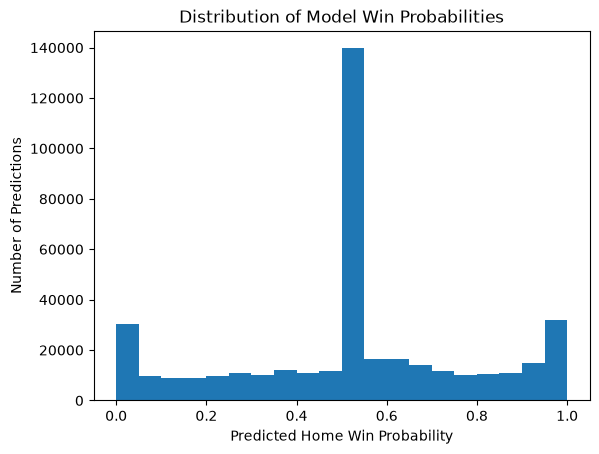

In [22]:
import matplotlib.pyplot as plt

plt.hist(
    home_win_probability,
    bins=20
)

plt.xlabel("Predicted Home Win Probability")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Model Win Probabilities")

plt.show()

In [23]:
prob_df = pd.DataFrame({
    "prediction": home_win_probability,
    "actual": y_test.values
})

prob_df["probability_bin"] = pd.cut(
    prob_df["prediction"],
    bins=10
)

calibration = prob_df.groupby(
    "probability_bin",
    observed=True
).agg(
    predicted_probability=("prediction", "mean"),
    actual_win_rate=("actual", "mean"),
    sample_size=("actual", "count")
)

calibration

,predicted_probability,actual_win_rate,sample_size
probability_bin,,,
"(-0.001, 0.1]",0.028922,0.020933,40224
"(0.1, 0.2]",0.150034,0.146832,17789
"(0.2, 0.3]",0.251711,0.244861,20869
"(0.3, 0.4]",0.352437,0.345256,22198
"(0.4, 0.5]",0.452559,0.439078,22381
"(0.5, 0.6]",0.540681,0.541715,156252
"(0.6, 0.7]",0.647251,0.653276,30419
"(0.7, 0.8]",0.748192,0.756239,21878
"(0.8, 0.9]",0.849697,0.861710,21209


In [24]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_test,
    home_win_probability
)

print("Brier Score:", brier)

Brier Score: 0.17715337049351154
